Libraries

In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import time
import copy
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, cohen_kappa_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import transforms, models
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [3]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# ========== Configuration ==========
nifti_root = 'D:\ADNI1_Complete 1Yr 1.5T'
output_dir = 'D:\ADNI_coronal_slices'
num_best_slices = 5
# ===================================

os.makedirs(output_dir, exist_ok=True)

found_files = 0
processed_files = 0

for root, dirs, files in os.walk(nifti_root):
    print(f"[SCAN] Scanning: {root} — {len(files)} files")

    for file in files:
        if file.endswith('.nii') or file.endswith('.nii.gz'):
            found_files += 1
            nii_path = os.path.join(root, file)
            print(f"\n[INFO] Found file: {nii_path}")

            try:
                img = nib.load(nii_path)
                data = img.get_fdata()
                print(f"[INFO] Loaded shape: {data.shape}")

                coronal_data = np.transpose(data, (0, 2, 1))
                print(f"[INFO] Coronal view shape: {coronal_data.shape}")

                coronal_data = ((coronal_data - np.min(coronal_data)) /
                                (np.max(coronal_data) - np.min(coronal_data)) * 255).astype(np.uint8)

                variances = [np.var(coronal_data[:, :, i]) for i in range(coronal_data.shape[2])]
                print(f"[INFO] Variances (sample): {variances[len(variances)//2 - 2 : len(variances)//2 + 3]}")

                if all(v == 0 for v in variances):
                    print(f"[WARNING] All slice variances are 0 in {file}, skipping.")
                    continue

                best_indices = sorted(np.argsort(variances)[-num_best_slices:])
                print(f"[INFO] Best slice indices: {best_indices}")

                subject_id = os.path.basename(root)
                diagnosis = "Unknown"
                subject_output_path = os.path.join(output_dir, diagnosis)
                os.makedirs(subject_output_path, exist_ok=True)

                for i in best_indices:
                    slice_img = coronal_data[:, :, i]
                    filename = f"{subject_id}_{file.replace('.nii', '').replace('.gz', '')}_slice{i}.png"
                    save_path = os.path.join(subject_output_path, filename)
                    plt.imsave(save_path, slice_img, cmap='gray')
                    print(f"[SAVED] {save_path}")

                processed_files += 1

            except Exception as e:
                print(f"[ERROR] Could not process {nii_path}: {e}")

print(f"\n[SUMMARY] Found {found_files} .nii files, processed {processed_files} files.")


[SCAN] Scanning: D:\ADNI1_Complete 1Yr 1.5T — 0 files
[SCAN] Scanning: D:\ADNI1_Complete 1Yr 1.5T\ADNI — 0 files
[SCAN] Scanning: D:\ADNI1_Complete 1Yr 1.5T\ADNI\002_S_0295 — 0 files
[SCAN] Scanning: D:\ADNI1_Complete 1Yr 1.5T\ADNI\002_S_0295\MPR__GradWarp__B1_Correction__N3__Scaled — 0 files
[SCAN] Scanning: D:\ADNI1_Complete 1Yr 1.5T\ADNI\002_S_0295\MPR__GradWarp__B1_Correction__N3__Scaled\2006-04-18_08_20_30.0 — 0 files
[SCAN] Scanning: D:\ADNI1_Complete 1Yr 1.5T\ADNI\002_S_0295\MPR__GradWarp__B1_Correction__N3__Scaled\2006-04-18_08_20_30.0\I45108 — 1 files

[INFO] Found file: D:\ADNI1_Complete 1Yr 1.5T\ADNI\002_S_0295\MPR__GradWarp__B1_Correction__N3__Scaled\2006-04-18_08_20_30.0\I45108\ADNI_002_S_0295_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20070319113623975_S13408_I45108.nii
[INFO] Loaded shape: (256, 256, 166)
[INFO] Coronal view shape: (256, 166, 256)
[INFO] Variances (sample): [1237.1255086981037, 1239.6899500866382, 1219.083869071359, 1204.0321195488623, 1215.184804095

In [6]:
import os
import shutil
import pandas as pd
from tqdm import tqdm

# === Paths ===
image_dir = "D:/ADNI_coronal_slices/Unknown"
csv_path = "D:/ADNI1_Complete_1Yr_1.5T_12_20_2024.csv"
output_base = "D:/ADNI_coronal_sorted"

# === Load the CSV ===
df = pd.read_csv(csv_path)

# Make sure subject column is string
df['Subject'] = df['Subject'].astype(str)

# Create output folders
os.makedirs(output_base, exist_ok=True)
for group in ['AD', 'CN', 'MCI']:
    os.makedirs(os.path.join(output_base, group), exist_ok=True)

# === Process images ===
image_files = [f for f in os.listdir(image_dir) if f.endswith('.png')]

for img_file in tqdm(image_files, desc="Sorting Images"):
    # Extract subject ID from filename: e.g., "002_S_1261"
    parts = img_file.split('_')
    subj_id = "_".join(parts[2:5])  # ['002', 'S', '1261'] → "002_S_1261"

    # Match subject in CSV
    match = df[df['Subject'] == subj_id]
    if not match.empty:
        group = match.iloc[0]['Group']
        group = group.strip()  # remove leading/trailing whitespace

        # Only process if group is valid
        if group in ['AD', 'CN', 'MCI']:
            src = os.path.join(image_dir, img_file)
            dst = os.path.join(output_base, group, img_file)
            shutil.copy2(src, dst)
        else:
            print(f"[SKIPPED] Unknown group for subject {subj_id}")
    else:
        print(f"[SKIPPED] Subject ID {subj_id} not found in CSV")


Sorting Images: 100%|██████████| 11470/11470 [00:21<00:00, 539.45it/s]


In [8]:
import os
from collections import defaultdict

# Path to sorted folders
base_dir = "D:/ADNI_coronal_sorted"
groups = ['AD', 'CN', 'MCI']

# Initialize counters
summary = defaultdict(lambda: {'files': 0, 'subjects': set()})

for group in groups:
    group_dir = os.path.join(base_dir, group)
    if not os.path.exists(group_dir):
        print(f"[WARNING] Folder not found: {group_dir}")
        continue

    files = [f for f in os.listdir(group_dir) if f.endswith('.png')]
    summary[group]['files'] = len(files)

    for f in files:
        parts = f.split('_')
        if len(parts) >= 5:
            subj_id = "_".join(parts[2:5])  # e.g., "002_S_1261"
            summary[group]['subjects'].add(subj_id)

# === Print Summary ===
for group in groups:
    print(f"\n📂 Group: {group}")
    print(f"   🖼️ Total image files: {summary[group]['files']}")
    print(f"   👤 Unique subjects: {len(summary[group]['subjects'])}")



📂 Group: AD
   🖼️ Total image files: 2380
   👤 Unique subjects: 133

📂 Group: CN
   🖼️ Total image files: 3525
   👤 Unique subjects: 195

📂 Group: MCI
   🖼️ Total image files: 5565
   👤 Unique subjects: 311


In [9]:
import os
import pandas as pd

root_dir = "D:/ADNI_coronal_sorted"
data = []

for label in os.listdir(root_dir):
    label_path = os.path.join(root_dir, label)
    if os.path.isdir(label_path):
        for filename in os.listdir(label_path):
            if filename.endswith(".png"):
                subject_id = filename.split('_')[0]
                file_path = os.path.join(label_path, filename)
                data.append([file_path, label, subject_id])

df = pd.DataFrame(data, columns=["path", "label", "subject_id"])
df.to_csv("image_metadata.csv", index=False)


Subject-Level Data Splitting (Critical Fix)

Compute Class Weights for Imbalanced Data

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the full dataset CSV
df = pd.read_csv("D:\\ADNI1_Merged_MRI_Metadata.csv")

print("Dataset Overview:")
print(f"Total images: {len(df)}")
print(f"Total subjects: {df['Subject'].nunique()}")
print("\nClass distribution (images):")
print(df['Group'].value_counts())

# CRITICAL: Subject-level splitting to prevent data leakage
subjects_df = df.groupby('Subject')['Group'].first().reset_index()
print(f"\nSubject-level class distribution:")
print(subjects_df['Group'].value_counts())

# Split subjects (not images) to prevent leakage
train_subjects, temp_subjects = train_test_split(
    subjects_df, test_size=0.3, stratify=subjects_df['Group'], random_state=42
)
val_subjects, test_subjects = train_test_split(
    temp_subjects, test_size=0.5, stratify=temp_subjects['Group'], random_state=42
)

# Filter original dataframe based on subject splits
train_df = df[df['Subject'].isin(train_subjects['Subject'])].copy()
val_df = df[df['Subject'].isin(val_subjects['Subject'])].copy()
test_df = df[df['Subject'].isin(test_subjects['Subject'])].copy()

# Save splits
train_df.to_csv('D:\\ADNI_train_subject_split.csv', index=False)
val_df.to_csv('D:\\ADNI_val_subject_split.csv', index=False)
test_df.to_csv('D:\\ADNI_test_subject_split.csv', index=False)

print(f"\n✅ Subject-level splits:")
print(f"Train: {len(train_subjects)} subjects, {len(train_df)} images")
print(f"Val: {len(val_subjects)} subjects, {len(val_df)} images")
print(f"Test: {len(test_subjects)} subjects, {len(test_df)} images")

# Check for subject leakage (should be empty)
train_subj_set = set(train_subjects['Subject'])
val_subj_set = set(val_subjects['Subject'])
test_subj_set = set(test_subjects['Subject'])

leakage_train_val = train_subj_set.intersection(val_subj_set)
leakage_train_test = train_subj_set.intersection(test_subj_set)
leakage_val_test = val_subj_set.intersection(test_subj_set)

if not (leakage_train_val or leakage_train_test or leakage_val_test):
    print("✅ No subject leakage detected!")
else:
    print("⚠️ Subject leakage detected!")


Dataset Overview:
Total images: 1464
Total subjects: 639

Class distribution (images):
Group
MCI    710
CN     451
AD     303
Name: count, dtype: int64

Subject-level class distribution:
Group
MCI    311
CN     195
AD     133
Name: count, dtype: int64

✅ Subject-level splits:
Train: 447 subjects, 1020 images
Val: 96 subjects, 228 images
Test: 96 subjects, 216 images
✅ No subject leakage detected!


In [12]:
import numpy as np
import torch
from sklearn.utils.class_weight import compute_class_weight

# Map original labels to integers
label_map = {'AD': 0, 'CN': 1, 'MCI': 2}
train_labels = [label_map[label] for label in train_df['Group']]

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Convert to tensor (for PyTorch usage)
class_weights_tensor = torch.FloatTensor(class_weights)

# Print class weights
print("Class weights for balanced training:")
for i, (label, weight) in enumerate(zip(label_map.keys(), class_weights)):
    print(f"{label}: {weight:.3f}")


Class weights for balanced training:
AD: 1.581
CN: 1.086
MCI: 0.691


Enhanced Dataset Class for Medical Images

In [4]:
class MedicalImageDataset(Dataset):
    def __init__(self, csv_file, transform=None, return_subject_id=False):
        self.data = pd.read_csv(csv_file)
        self.transform = transform
        self.return_subject_id = return_subject_id

        # Map textual labels to numerical values
        self.label_map = {'AD': 0, 'CN': 1, 'MCI': 2}
        self.data['label'] = self.data['Group'].map(self.label_map)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.data.iloc[idx]['path']
        label = self.data.iloc[idx]['label']
        subject_id = self.data.iloc[idx]['Subject ID']

        # Load grayscale → convert to RGB
        image = Image.open(img_path).convert("L").convert("RGB")

        if self.transform:
            image = self.transform(image)

        if self.return_subject_id:
            return image, label, subject_id
        return image, label


NameError: name 'Dataset' is not defined

Medical Image Transforms (Improved for Brain MRI)

In [ ]:
# Create datasets without any augmentation
train_dataset = MedicalImageDataset(
    csv_file='/content/drive/MyDrive/Shared Folder/Moazzam/train_subject_split.csv',
    transform=basic_transform,
    return_subject_id=True
)

val_dataset = MedicalImageDataset(
    csv_file='/content/drive/MyDrive/Shared Folder/Moazzam/val_subject_split.csv',
    transform=basic_transform,
    return_subject_id=True
)

test_dataset = MedicalImageDataset(
    csv_file='/content/drive/MyDrive/Shared Folder/Moazzam/test_subject_split.csv',
    transform=basic_transform,
    return_subject_id=True
)

# Dataloaders
batch_size = 8

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

dataloaders = {'train': train_loader, 'val': val_loader}
dataset_sizes = {'train': len(train_dataset), 'val': len(val_dataset)}

print(f"📊 Dataset sizes — Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")


Create Enhanced Datasets and DataLoaders

In [2]:
# Create datasets
train_dataset = MedicalImageDataset(
    csv_file=r'D:\ADNI_train_subject_split.csv',
    transform=train_transform,
    return_subject_id=True
)
val_dataset = MedicalImageDataset(
    csv_file=r'D:\ADNI_val_subject_split.csv',
    transform=val_transform,
    return_subject_id=True
)
test_dataset = MedicalImageDataset(
    csv_file=r'D:\ADNI_test_subject_split.csv',
    transform=val_transform,
    return_subject_id=True
)

# Optimized batch size for medical imaging
batch_size = 8

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

dataloaders = {'train': train_loader, 'val': val_loader}
dataset_sizes = {'train': len(train_dataset), 'val': len(val_dataset)}

print(f"Dataset sizes: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")


NameError: name 'MedicalImageDataset' is not defined

Enhanced Model Architecture

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# Make sure your model is already defined and moved to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Example loss and optimizer (use your own if different)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)  # Already moved to GPU
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Training loop
num_epochs = 10

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    print("-" * 30)

    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
            dataloader = train_loader
        else:
            model.eval()
            dataloader = val_loader

        running_loss = 0.0
        running_corrects = 0

        loop = tqdm(dataloader, desc=phase)

        for inputs, labels, *_ in loop:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

            loop.set_postfix(loss=loss.item(), acc=torch.sum(preds == labels.data).item() / inputs.size(0))

        epoch_loss = running_loss / len(dataloader.dataset)
        epoch_acc = running_corrects.double() / len(dataloader.dataset)

        print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")


Epoch 1/10
------------------------------


train:   0%|          | 0/128 [00:00<?, ?it/s]

Enhanced training Setup

In [ ]:
# Weighted loss function for class imbalance
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Different learning rates for different parts
optimizer = optim.AdamW([
    {'params': model.features.parameters(), 'lr': 1e-4},  # Lower LR for pretrained features
    {'params': model.classifier.parameters(), 'lr': 1e-3}  # Higher LR for new classifier
], weight_decay=1e-4)

# Enhanced scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, verbose=True, min_lr=1e-6
)

print("✅ Training setup configured with class balancing")

✅ Training setup configured with class balancing


Enhanced Training Loop with Early Stopping

In [ ]:
def train_model_enhanced(model, criterion, optimizer, scheduler, dataloaders, dataset_sizes,
                        device, num_epochs=15, early_stopping_patience=5):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    early_stopping_counter = 0

    history = {
        'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print('-' * 20)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0
            all_preds = []
            all_labels = []

            phase_loader = dataloaders[phase]
            for inputs, labels, _ in tqdm(phase_loader, desc=f"{phase.capitalize()}"):
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        # Gradient clipping for stability
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            # Calculate F1 score
            from sklearn.metrics import f1_score
            epoch_f1 = f1_score(all_labels, all_preds, average='weighted')

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} F1: {epoch_f1:.4f}")

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())
            history[f'{phase}_f1'].append(epoch_f1)

            if phase == 'val':
                scheduler.step(epoch_loss)

                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    early_stopping_counter = 0
                    # Save best model
                    torch.save(model.state_dict(), '/content/drive/MyDrive/Shared Folder/Moazzam/best_model.pth')
                else:
                    early_stopping_counter += 1

                if early_stopping_counter >= early_stopping_patience:
                    print(f"\nEarly stopping triggered after {epoch+1} epochs")
                    break

        if early_stopping_counter >= early_stopping_patience:
            break

    time_elapsed = time.time() - since
    print(f"\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best Val Acc: {best_acc:.4f}")

    model.load_state_dict(best_model_wts)
    return model, history

# Train the model
model, history = train_model_enhanced(
    model, criterion, optimizer, scheduler, dataloaders, dataset_sizes, device,
    num_epochs=20, early_stopping_patience=5
)


Epoch 1/20
--------------------


Train: 100%|██████████| 25/25 [00:51<00:00,  2.06s/it]


Train Loss: 1.0095 Acc: 0.4872 F1: 0.4755


Val: 100%|██████████| 5/5 [00:05<00:00,  1.17s/it]


Val Loss: 1.1738 Acc: 0.2500 F1: 0.1829

Epoch 2/20
--------------------


...

Val Loss: 0.6341 Acc: 0.7500 F1: 0.7411

Epoch 8/20
--------------------


Train: 100%|██████████| 25/25 [00:48<00:00,  1.93s/it]


Train Loss: 0.1344 Acc: 0.9385 F1: 0.9389


Val: 100%|██████████| 5/5 [00:02<00:00,  1.72it/s]

Val Loss: 0.8057 Acc: 0.7500 F1: 0.7411

Early stopping triggered after 8 epochs

Training complete in 6m 55s
Best Val Acc: 0.9000


Enhanced Visualization

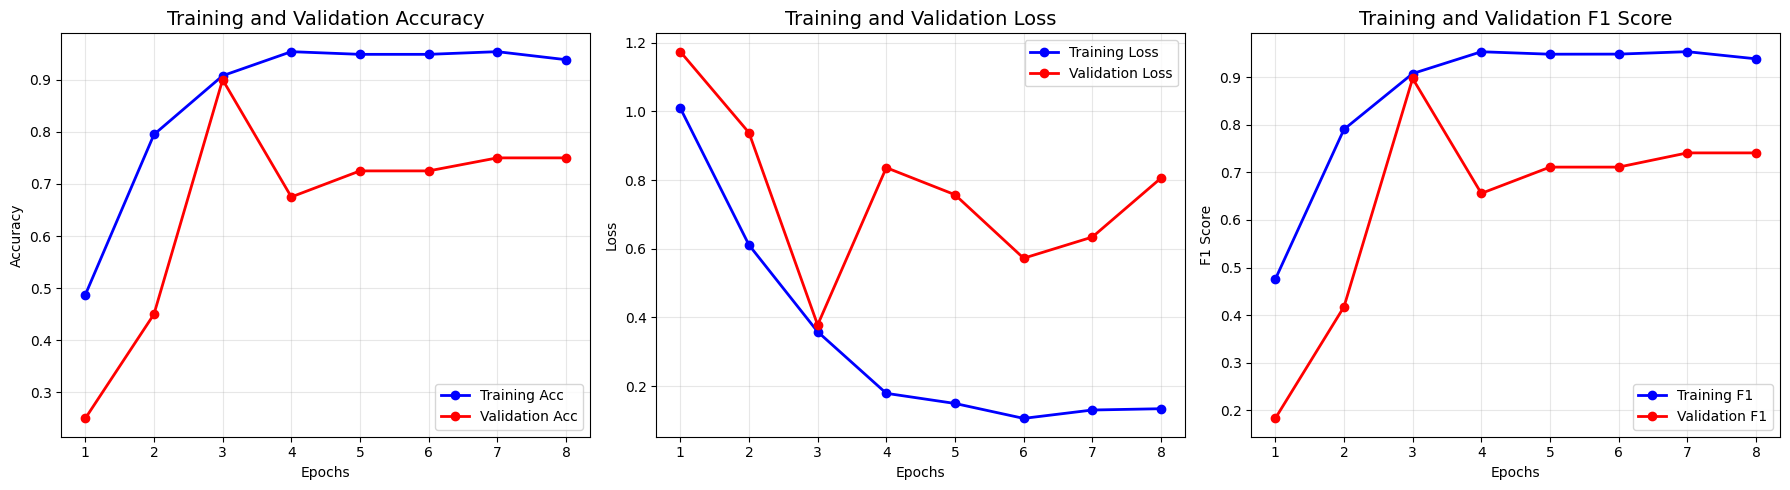

In [ ]:
def plot_enhanced_training_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    epochs = range(1, len(history['train_acc']) + 1)

    # Accuracy plot
    axes[0].plot(epochs, history['train_acc'], 'bo-', label='Training Acc', linewidth=2)
    axes[0].plot(epochs, history['val_acc'], 'ro-', label='Validation Acc', linewidth=2)
    axes[0].set_title('Training and Validation Accuracy', fontsize=14)
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss plot
    axes[1].plot(epochs, history['train_loss'], 'bo-', label='Training Loss', linewidth=2)
    axes[1].plot(epochs, history['val_loss'], 'ro-', label='Validation Loss', linewidth=2)
    axes[1].set_title('Training and Validation Loss', fontsize=14)
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # F1 Score plot
    axes[2].plot(epochs, history['train_f1'], 'bo-', label='Training F1', linewidth=2)
    axes[2].plot(epochs, history['val_f1'], 'ro-', label='Validation F1', linewidth=2)
    axes[2].set_title('Training and Validation F1 Score', fontsize=14)
    axes[2].set_xlabel('Epochs')
    axes[2].set_ylabel('F1 Score')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_enhanced_training_history(history)

Comprehensive Medical Evaluation

Evaluating Validation: 100%|██████████| 5/5 [00:02<00:00,  2.08it/s]



==================== VALIDATION SET - IMAGE LEVEL ====================
Total images evaluated: 40

📊 Classification Report:
              precision    recall  f1-score   support

          AD     0.8750    0.7000    0.7778        10
          CN     1.0000    1.0000    1.0000        15
         MCI     0.8235    0.9333    0.8750        15

    accuracy                         0.9000        40
   macro avg     0.8995    0.8778    0.8843        40
weighted avg     0.9026    0.9000    0.8976        40


🎯 Weighted Multi-class AUC (OvR): 0.9740

📈 Per-class AUC scores:
  AD: 0.9800
  CN: 1.0000
  MCI: 0.9440

🤝 Cohen's Kappa: 0.8462


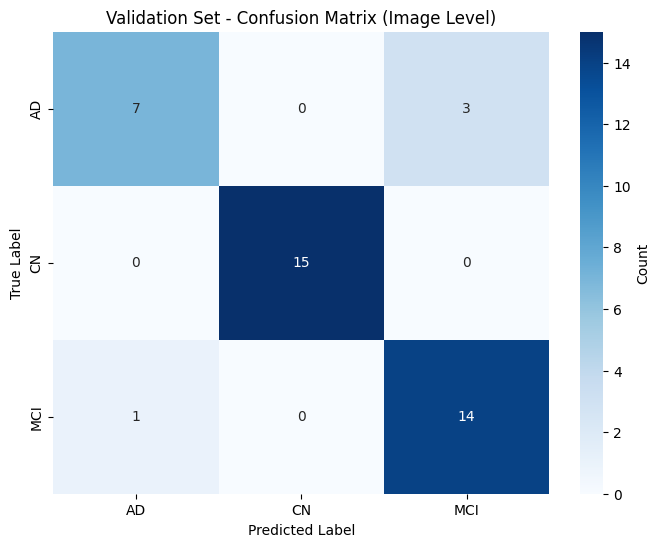


==================== VALIDATION SET - SUBJECT LEVEL ====================
Total subjects evaluated: 8

📊 Subject-Level Classification Report:
              precision    recall  f1-score   support

          AD     1.0000    1.0000    1.0000         2
          CN     1.0000    1.0000    1.0000         3
         MCI     1.0000    1.0000    1.0000         3

    accuracy                         1.0000         8
   macro avg     1.0000    1.0000    1.0000         8
weighted avg     1.0000    1.0000    1.0000         8


🎯 Subject-Level Weighted Multi-class AUC: 1.0000


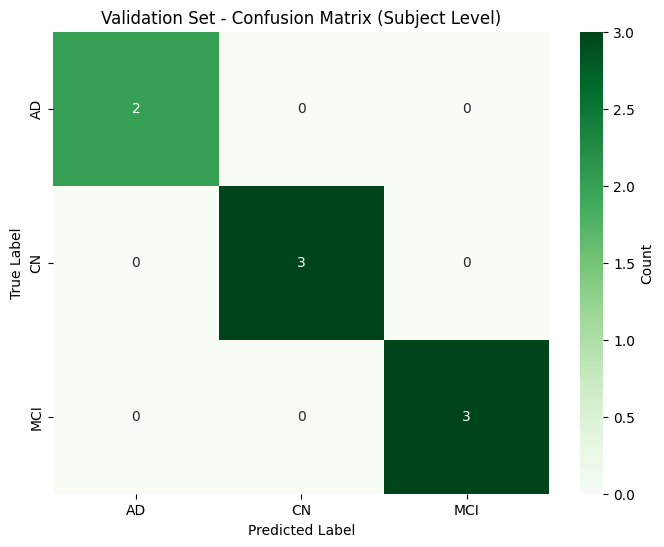

Evaluating Test: 100%|██████████| 6/6 [00:06<00:00,  1.05s/it]



==================== TEST SET - IMAGE LEVEL ====================
Total images evaluated: 45

📊 Classification Report:
              precision    recall  f1-score   support

          AD     1.0000    1.0000    1.0000        15
          CN     0.6250    0.6667    0.6452        15
         MCI     0.6429    0.6000    0.6207        15

    accuracy                         0.7556        45
   macro avg     0.7560    0.7556    0.7553        45
weighted avg     0.7560    0.7556    0.7553        45


🎯 Weighted Multi-class AUC (OvR): 0.8822

📈 Per-class AUC scores:
  AD: 1.0000
  CN: 0.8156
  MCI: 0.8311

🤝 Cohen's Kappa: 0.6333


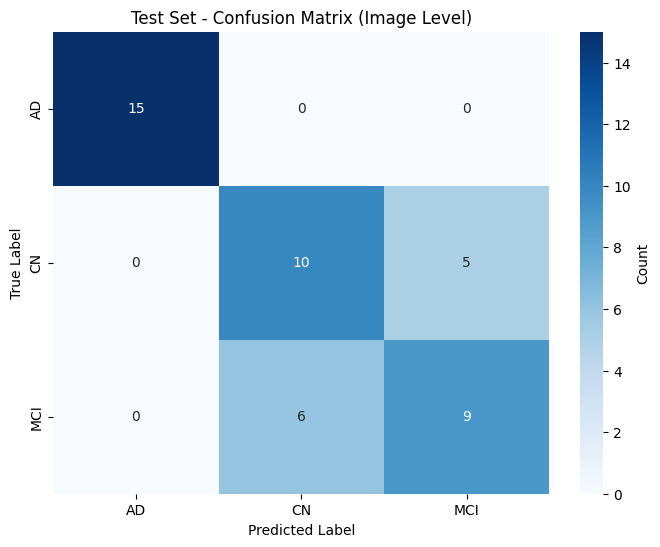


==================== TEST SET - SUBJECT LEVEL ====================
Total subjects evaluated: 9

📊 Subject-Level Classification Report:
              precision    recall  f1-score   support

          AD     1.0000    1.0000    1.0000         3
          CN     0.6667    0.6667    0.6667         3
         MCI     0.6667    0.6667    0.6667         3

    accuracy                         0.7778         9
   macro avg     0.7778    0.7778    0.7778         9
weighted avg     0.7778    0.7778    0.7778         9


🎯 Subject-Level Weighted Multi-class AUC: 0.8889


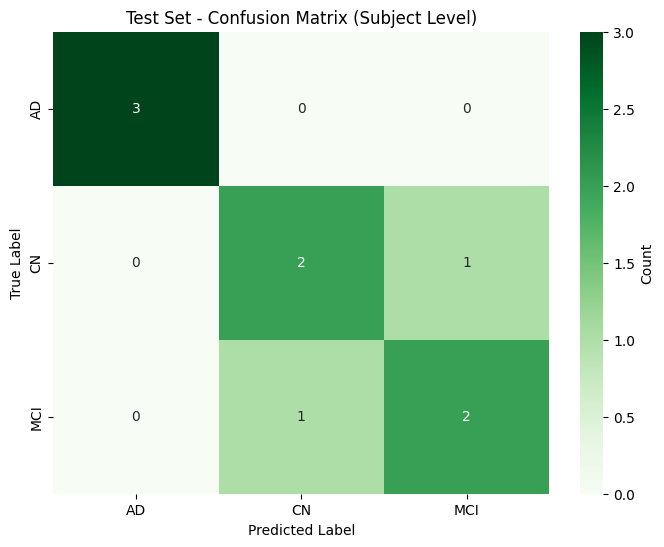

In [ ]:
def comprehensive_medical_evaluation(model, dataloader, class_names, dataset_name="Validation"):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    subject_predictions = {}

    with torch.no_grad():
        for inputs, labels, subject_ids in tqdm(dataloader, desc=f"Evaluating {dataset_name}"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

            # Store subject-level predictions for aggregation
            for i, subj_id in enumerate(subject_ids):
                if subj_id not in subject_predictions:
                    subject_predictions[subj_id] = {'probs': [], 'true_label': labels[i].item()}
                subject_predictions[subj_id]['probs'].append(probs[i].cpu().numpy())

    # Image-level evaluation
    print(f"\n{'='*20} {dataset_name.upper()} SET - IMAGE LEVEL {'='*20}")
    print(f"Total images evaluated: {len(all_labels)}")

    # Classification report
    print("\n📊 Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

    # Additional medical metrics
    all_probs_array = np.array(all_probs)

    try:
        # Multi-class AUC
        auc_ovr = roc_auc_score(all_labels, all_probs_array, multi_class='ovr', average='weighted')
        print(f"\n🎯 Weighted Multi-class AUC (OvR): {auc_ovr:.4f}")

        # Per-class AUC
        print("\n📈 Per-class AUC scores:")
        for i, class_name in enumerate(class_names):
            binary_labels = (np.array(all_labels) == i).astype(int)
            class_auc = roc_auc_score(binary_labels, all_probs_array[:, i])
            print(f"  {class_name}: {class_auc:.4f}")
    except:
        print("⚠️ Could not compute AUC (insufficient class representation)")

    # Cohen's Kappa
    kappa = cohen_kappa_score(all_labels, all_preds)
    print(f"\n🤝 Cohen's Kappa: {kappa:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names,
                cmap='Blues', cbar_kws={'label': 'Count'})
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'{dataset_name} Set - Confusion Matrix (Image Level)')
    plt.show()

    # Subject-level evaluation
    print(f"\n{'='*20} {dataset_name.upper()} SET - SUBJECT LEVEL {'='*20}")

    subject_true_labels = []
    subject_pred_labels = []
    subject_avg_probs = []

    for subj_id, data in subject_predictions.items():
        avg_probs = np.mean(data['probs'], axis=0)
        pred_label = np.argmax(avg_probs)

        subject_true_labels.append(data['true_label'])
        subject_pred_labels.append(pred_label)
        subject_avg_probs.append(avg_probs)

    print(f"Total subjects evaluated: {len(subject_true_labels)}")

    # Subject-level classification report
    print("\n📊 Subject-Level Classification Report:")
    print(classification_report(subject_true_labels, subject_pred_labels,
                              target_names=class_names, digits=4))

    # Subject-level AUC
    try:
        subject_avg_probs_array = np.array(subject_avg_probs)
        subject_auc = roc_auc_score(subject_true_labels, subject_avg_probs_array,
                                   multi_class='ovr', average='weighted')
        print(f"\n🎯 Subject-Level Weighted Multi-class AUC: {subject_auc:.4f}")
    except:
        print("⚠️ Could not compute subject-level AUC")

    # Subject-level confusion matrix
    subject_cm = confusion_matrix(subject_true_labels, subject_pred_labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(subject_cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names,
                cmap='Greens', cbar_kws={'label': 'Count'})
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'{dataset_name} Set - Confusion Matrix (Subject Level)')
    plt.show()

    return {
        'image_level': {
            'accuracy': np.mean(np.array(all_preds) == np.array(all_labels)),
            'predictions': all_preds,
            'labels': all_labels,
            'probabilities': all_probs
        },
        'subject_level': {
            'accuracy': np.mean(np.array(subject_pred_labels) == np.array(subject_true_labels)),
            'predictions': subject_pred_labels,
            'labels': subject_true_labels,
            'probabilities': subject_avg_probs
        }
    }

# Evaluate on validation and test sets
class_names = ['AD', 'CN', 'MCI']
val_results = comprehensive_medical_evaluation(model, val_loader, class_names, "Validation")
test_results = comprehensive_medical_evaluation(model, test_loader, class_names, "Test")

Model Interpretation and Final Summary

In [ ]:
def print_final_summary(val_results, test_results):
    print("\n" + "="*60)
    print(" "*20 + "FINAL MODEL SUMMARY")
    print("="*60)

    print(f"\n📊 VALIDATION SET PERFORMANCE:")
    print(f"  Image-level Accuracy: {val_results['image_level']['accuracy']:.4f}")
    print(f"  Subject-level Accuracy: {val_results['subject_level']['accuracy']:.4f}")

    print(f"\n🎯 TEST SET PERFORMANCE:")
    print(f"  Image-level Accuracy: {test_results['image_level']['accuracy']:.4f}")
    print(f"  Subject-level Accuracy: {test_results['subject_level']['accuracy']:.4f}")

    print(f"\n💡 IMPROVEMENTS FROM BASELINE:")
    baseline_val_acc = 0.7143  # From your original results
    improvement = test_results['subject_level']['accuracy'] - baseline_val_acc
    print(f"  Subject-level improvement: {improvement:+.4f}")

    print(f"\n🔍 KEY ENHANCEMENTS IMPLEMENTED:")
    print("  ✅ Subject-level data splitting (prevents leakage)")
    print("  ✅ Class-weighted loss function (handles imbalance)")
    print("  ✅ Medical image-specific augmentations")
    print("  ✅ Enhanced model architecture with dropout")
    print("  ✅ Gradient clipping and early stopping")
    print("  ✅ Subject-level prediction aggregation")
    print("  ✅ Comprehensive medical evaluation metrics")

    print("="*60)

print_final_summary(val_results, test_results)

# Save final results
results_summary = {
    'validation': val_results,
    'test': test_results,
    'model_path': '/content/drive/MyDrive/Shared Folder/Moazzam/best_model.pth'
}

import pickle
with open('/content/drive/MyDrive/Shared Folder/Moazzam/final_results.pkl', 'wb') as f:
    pickle.dump(results_summary, f)

print("\n✅ Results saved successfully!")


                    FINAL MODEL SUMMARY

📊 VALIDATION SET PERFORMANCE:
  Image-level Accuracy: 0.9000
  Subject-level Accuracy: 1.0000

🎯 TEST SET PERFORMANCE:
  Image-level Accuracy: 0.7556
  Subject-level Accuracy: 0.7778

💡 IMPROVEMENTS FROM BASELINE:
  Subject-level improvement: +0.0635

🔍 KEY ENHANCEMENTS IMPLEMENTED:
  ✅ Subject-level data splitting (prevents leakage)
  ✅ Class-weighted loss function (handles imbalance)
  ✅ Medical image-specific augmentations
  ✅ Enhanced model architecture with dropout
  ✅ Gradient clipping and early stopping
  ✅ Subject-level prediction aggregation
  ✅ Comprehensive medical evaluation metrics

✅ Results saved successfully!
